In [11]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor 
from sklearn.metrics import mean_squared_error, r2_score

    brand  year  mileage fuel_type transmission   price
0   Honda  2005  98858.0    Petrol    Automatic  608021
1    Tata  2005  29065.0    Diesel       Manual  747666
2  Maruti  2006  93460.0    Petrol       Manual  587107
3   Honda  2016  98092.0    Diesel    Automatic  383189
4   Honda  2010  64693.0    Petrol    Automatic  592447

 results: 
mean squared error:  713761022.3303034
r2 score:  0.9539514557662875


C:\Users\Hp\AppData\Local\Temp\ipykernel_19524\1330945380.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["fuel_type"].fillna(df["fuel_type"].mode()[0], inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_19524\1330945380.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

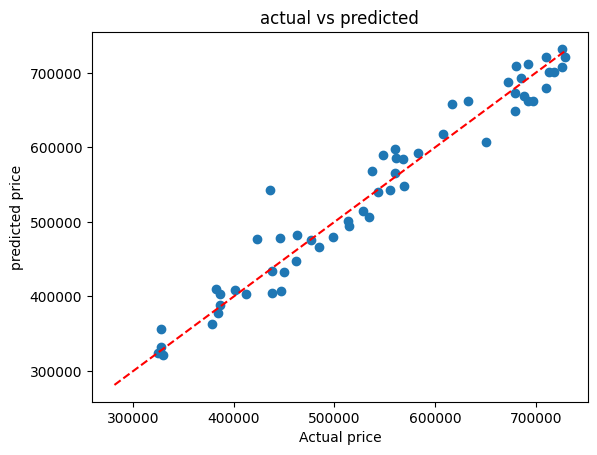

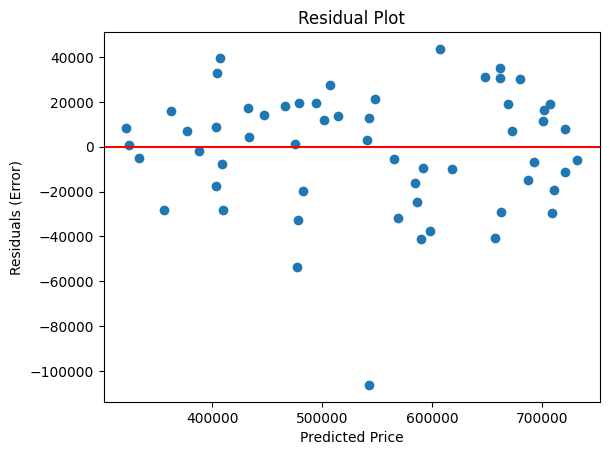

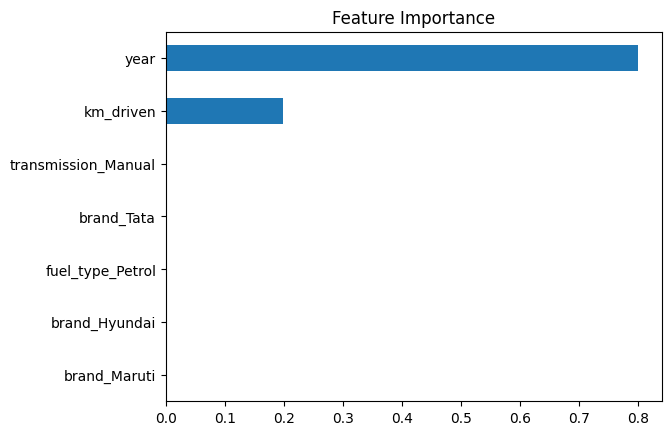

In [ ]:
df = pd.read_csv("vechicle_price_pred.csv")

print(df.head())
# print(df.info())
# print(df.describe())
# print(df.isnull().sum())
# print(df.columns)


#preprocessing
df.rename(columns={"mileage":"km_driven"}, inplace=True)
# print(df.columns)

# Replace all missing fuel types with the most common fuel type
df["fuel_type"].fillna(df["fuel_type"].mode()[0], inplace=True)

df["transmission"].fillna(df["transmission"].mode()[0], inplace=True)

df["km_driven"].fillna(df["km_driven"].median(), inplace=True)

df = df[df["price"] < df["price"].quantile(0.95)]
# print(df.isnull().sum())

# Convert categorical columns into numeric columns using one-hot encoding
# and remove one column to avoid redundancy
df = pd.get_dummies(df, drop_first=True)

# X = all columns except price → inputs  
# y = only price → output
X= df.drop("price", axis=1)
y = df["price"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)

model.fit(X_train, y_train)
import pickle

pickle.dump(model, open("model.pkl", "wb"))

y_pred = model.predict(X_test)

print("\n results: ")
print("mean squared error: ", mean_squared_error(y_test, y_pred))
print("r2 score: ", r2_score(y_test, y_pred))
# print()


import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.title("actual vs predicted")

plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")
plt.show()



# Residual plot = check if model is making systematic mistakes
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")

plt.axhline(y=0, color='red')
plt.show()


# ------------------------------------------feature importance -------------------------------------------------
import pandas as pd

importances = model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values().plot(kind='barh')


plt.title("Feature Importance")
plt.show()
